In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
covertype = fetch_ucirepo(id=31) 
  
# data (as pandas dataframes) 
X = covertype.data.features 
y = covertype.data.targets 
  
# metadata 
print(covertype.metadata) 
  
# variable information 
print(covertype.variables) 


{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [5]:
print("X shape",X.shape)
print("Y shape",y.shape)

X shape (581012, 54)
Y shape (581012, 1)


In [8]:
print("first 5 rows of x : ")
display(X.head())

print("\nfirst 5 rows of y :")
display(y.head())

first 5 rows of x : 


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,0
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,0
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,0
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,0
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,0



first 5 rows of y :


,Cover_Type
0,5
1,5
2,2
3,2
4,5


In [9]:
print("unique classes : ")
print(y.iloc[:,0].unique())

unique classes : 
[5 2 1 7 3 6 4]


In [10]:
class_counts = y.iloc[:,0].value_counts().sort_index()
print("class distribution")
print(class_counts)

class distribution
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


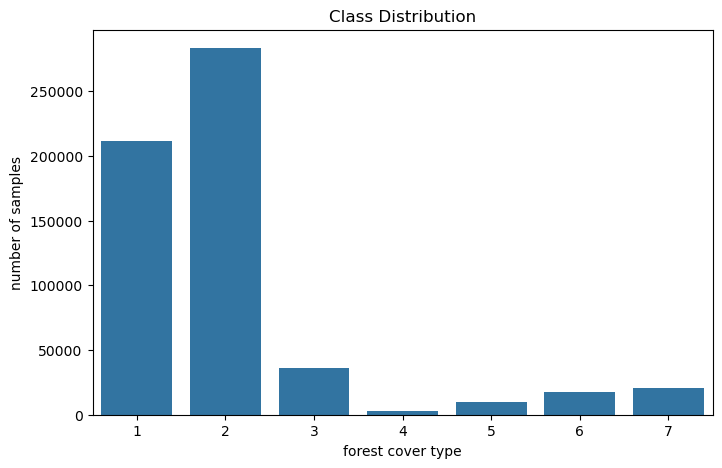

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(x=class_counts.index,
            y=class_counts.values,)
plt.xlabel("forest cover type")
plt.ylabel("number of samples")
plt.title("Class Distribution")
plt.show()

In [12]:
most_frequent = class_counts.max()
least_frequent = class_counts.min()

imbalance_ratio = most_frequent / least_frequent

print("Most frequent class:", most_frequent)
print("Least frequent class:", least_frequent)
print("Imbalance ratio:", imbalance_ratio)


Most frequent class: 283301
Least frequent class: 2747
Imbalance ratio: 103.13105205678923


In [13]:
y = y.iloc[:, 0].values - 1

print("Unique classes after conversion:")
print(np.unique(y))

Unique classes after conversion:
[0 1 2 3 4 5 6]


In [14]:
X = X.values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (581012, 54)
y shape: (581012,)


In [15]:
num_classes = 7

y_onehot = np.eye(num_classes)[y]

print("One-hot encoded shape:", y_onehot.shape)
print(y_onehot[:5])


One-hot encoded shape: (581012, 7)
[[0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]]


In [22]:
y_onehot = np.eye(7)[y]

print(X.shape)
print(y.shape)
print(y_onehot.shape)


(581012, 54)
(581012,)
(581012, 7)


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set shape: (464809, 54)
Test set shape: (116203, 54)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


baseline_model = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42, n_jobs=-1)
baseline_model.fit(X_train_scaled, y_train)


y_pred = baseline_model.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline Accuracy: 0.7235

Classification Report:
              precision    recall  f1-score   support

          -1       0.71      0.70      0.70     42368
           0       0.75      0.80      0.77     56661
           1       0.68      0.80      0.73      7151
           2       0.61      0.44      0.51       549
           3       0.15      0.01      0.01      1899
           4       0.50      0.27      0.35      3473
           5       0.74      0.56      0.63      4102

    accuracy                           0.72    116203
   macro avg       0.59      0.51      0.53    116203
weighted avg       0.71      0.72      0.71    116203



In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9548

Classification Report:
              precision    recall  f1-score   support

          -1       0.97      0.94      0.95     42368
           0       0.95      0.97      0.96     56661
           1       0.93      0.96      0.95      7151
           2       0.90      0.84      0.87       549
           3       0.95      0.79      0.86      1899
           4       0.93      0.88      0.91      3473
           5       0.97      0.95      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.94      0.91      0.92    116203
weighted avg       0.95      0.95      0.95    116203



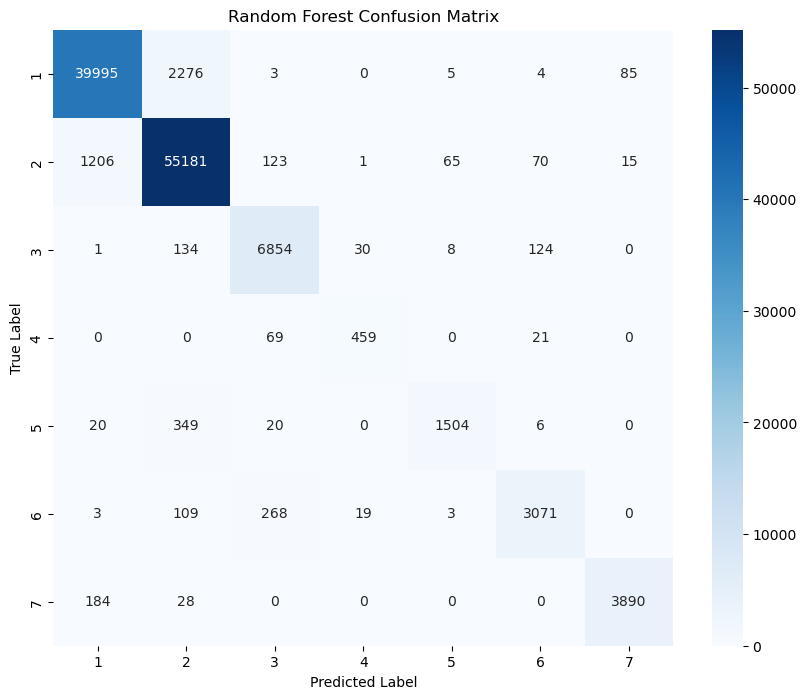

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()


In [27]:

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

subset_indices = np.random.choice(len(X_train_scaled), size=10000, replace=False)
X_train_subset = X_train_scaled[subset_indices]
y_train_subset = y_train[subset_indices]

rf_tune = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=rf_tune, 
    param_distributions=param_dist, 
    n_iter=5, 
    cv=3, 
    random_state=42, 
    n_jobs=-1,
    scoring='accuracy'
)

random_search.fit(X_train_subset, y_train_subset)

print("Best Parameters:", random_search.best_params_)
print(f"Best Subset Accuracy: {random_search.best_score_:.4f}")

Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best Subset Accuracy: 0.7951


In [28]:
best_params = random_search.best_params_

final_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_scaled, y_train)

y_pred_final = final_model.predict(X_test_scaled)

print(f"Final Optimized Random Forest Accuracy: {accuracy_score(y_test, y_pred_final):.4f}\n")
print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))

Final Optimized Random Forest Accuracy: 0.9553

Final Classification Report:
              precision    recall  f1-score   support

          -1       0.97      0.94      0.96     42368
           0       0.95      0.97      0.96     56661
           1       0.94      0.96      0.95      7151
           2       0.90      0.84      0.87       549
           3       0.95      0.79      0.86      1899
           4       0.93      0.89      0.91      3473
           5       0.97      0.95      0.96      4102

    accuracy                           0.96    116203
   macro avg       0.94      0.91      0.92    116203
weighted avg       0.96      0.96      0.96    116203



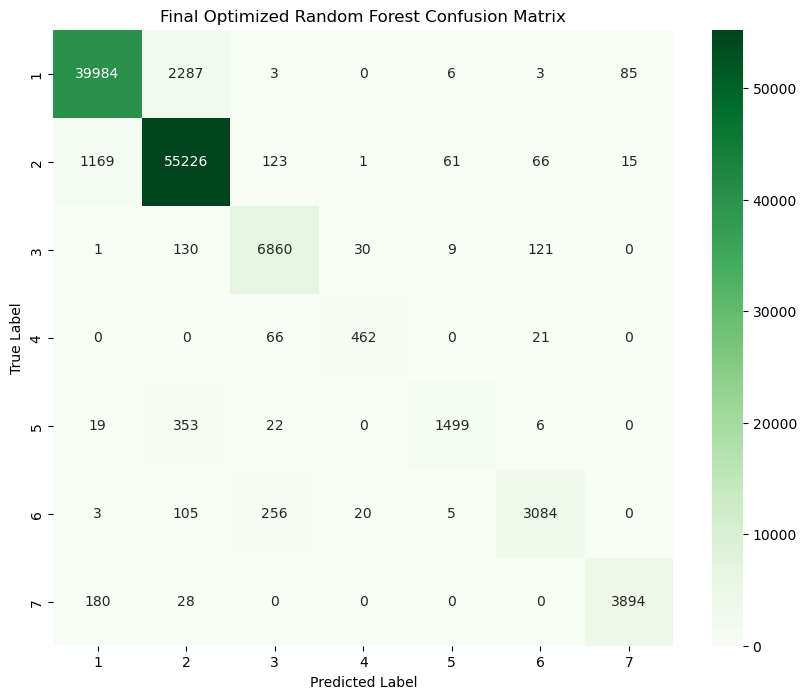

In [29]:
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens', xticklabels=range(1, 8), yticklabels=range(1, 8))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Optimized Random Forest Confusion Matrix')
plt.show()